This cell handles the initial imports and verifies the environment. Checking library versions is a best practice in Data Science to ensure that the model you loaded (.pkl file) was built using the same version of scikit-learn, which prevents "Inconsistent Version" errors.

In [ ]:
import pandas as pd     # For data manipulation and DataFrame creation
import sklearn          # The core machine learning library
import joblib           # Used specifically for loading and saving trained models

# Print library versions to ensure compatibility with the saved model
print(f"Pandas version: {pd.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

# Confirm that the environment is ready for the dashboard
print("All libraries imported successfully!")

Pandas version: 2.3.3
Scikit-learn version: 1.8.0
All libraries imported successfully!


Data Loading & Preprocessing
This stage is the foundation of the entire Machine Learning pipeline. We are pulling the raw Telco Churn dataset, fixing data type inconsistencies (specifically for TotalCharges), and partitioning the data so the model has "unseen" examples to practice on later.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Source: Load the dataset from a stable IBM Cloud repository
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    df = pd.read_csv(url)
    print("✅ Dataset loaded successfully!")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Data Cleaning: 
# TotalCharges often contains empty strings (" ") which cause errors.
# 'errors=coerce' turns those spaces into NaN (Not a Number), then we drop them.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True) 

# Feature Selection & Target Encoding
# We remove 'customerID' because it's a unique identifier with no predictive power.
X = df.drop(['customerID', 'Churn'], axis=1)

# Convert the target 'Churn' from strings ('Yes'/'No') into binary integers (1/0)
y = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Data Splitting:
# 80% of data is used for training (X_train), 20% for final evaluation (X_test).
# random_state=42 ensures the split is the same every time you run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Output Summary
print(f"✔️ Training features shape: {X_train.shape}")
print(f"📈 Target distribution: {y.value_counts(normalize=True).to_dict()}")

Dataset loaded successfully!
Training features shape: (5625, 19)
Target distribution: {0: 0.7342150170648464, 1: 0.26578498293515357}


Preprocessing Pipeline Construction
This cell builds the automated engine that transforms raw data into a format a machine learning model can understand. By using a ColumnTransformer and Pipeline, we ensure that the exact same cleaning steps are applied to both the training data and any new data entered into your dashboard later.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Automated Column Identification:
# We split columns into numbers (tenure, charges) and categories (gender, contract).
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# Numeric Pipeline:
# - imputer: Fills any missing numbers with the 'median' value.
# - scaler: Normalizes numbers so large values (TotalCharges) don't overpower small ones (Tenure).
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline:
# - imputer: Fills missing text with the word 'missing'.
# - onehot: Converts text labels into 0s and 1s. 
# - handle_unknown='ignore': This is crucial! It prevents the dashboard from crashing 
#   if a user selects a value the model hasn't seen before (like 'Non-binary').
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# The Preprocessing Engine:
# Combines the numeric and categorical paths into a single object.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("✅ Preprocessing engine defined and ready for integration.")

Preprocessing engine defined.


Model Training & Hyperparameter Tuning
This is where the "learning" actually happens. We are combining the preprocessing engine from the previous step with a Random Forest Classifier. Instead of just picking a single model, we use GridSearchCV to automatically test different configurations (hyperparameters) to find the "sweet spot" for accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Full Pipeline Construction:
# We link the 'preprocessor' (cleaning/scaling) directly to the 'classifier' (the model).
# This creates a "black box" that can take raw data and output a churn prediction.
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Hyperparameter Grid:
# We tell Scikit-Learn to try different "knobs" on the Random Forest:
# - n_estimators: Number of trees in the forest.
# - max_depth: How deep each tree can grow (prevents overfitting).
# - min_samples_split: Minimum data points required to split a branch.
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

# Grid Search Execution:
# - cv=3: Performs 3-fold Cross-Validation (splits data to ensure stability).
# - n_jobs=-1: Uses all available CPU cores to speed up the process.
print("Starting Grid Search (Optimization)...")
grid_search = GridSearchCV(full_pipeline, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Results:
# Displays the highest accuracy achieved during the tuning process.
print(f"\n✅ Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"⚙️ Best Parameters found: {grid_search.best_params_}")

Starting Grid Search...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best Cross-Validation Accuracy: 0.8041
Best Parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


In [7]:
import joblib

# Export the best estimator found by GridSearch
joblib.dump(grid_search.best_estimator_, 'churn_pipeline_model.pkl')

print("Model exported as 'churn_pipeline_model.pkl'. You are ready for production!")

Model exported as 'churn_pipeline_model.pkl'. You are ready for production!


📉 Model Evaluation & Performance Metrics
After training and tuning, we must verify if the model actually works on data it has never seen before (X_test). This cell generates two critical tools: a Classification Report for a statistical breakdown and a Confusion Matrix to visualize where the model is getting confused.

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



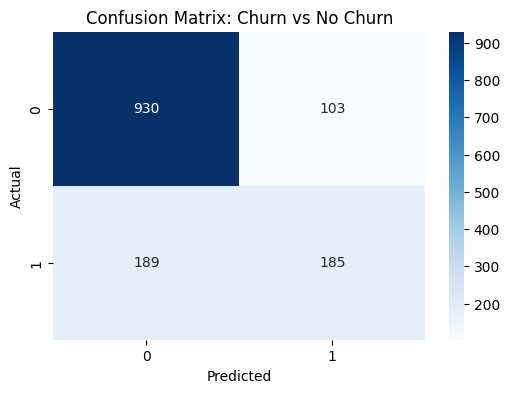

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Final Prediction:
# We use the 'best_estimator_' found by GridSearch to predict outcomes for the test set.
y_pred = grid_search.predict(X_test)

# Detailed Statistical Report:
# - Precision: How many predicted "Churn" were actually churn?
# - Recall: How many actual "Churn" cases did we successfully catch?
# - F1-Score: The harmonic mean of Precision and Recall (best for imbalanced data).
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Visualizing Errors (Confusion Matrix):
# This heatmap shows:
# [True Negatives,  False Positives]
# [False Negatives, True Positives ]
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Churn vs No Churn')
plt.show()

Interactive Prediction Dashboard
This is the final deployment stage of the project. It features a professional, tabbed interface that allows users to input real-world customer data across Personal, Services, and Billing categories. By integrating the saved pipeline, the dashboard provides instant, color-coded churn risk assessments without requiring any manual data preprocessing.

In [20]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import joblib

# Load the trained model pipeline
# This pipeline includes the preprocessor and the classifier
try:
    model = joblib.load('churn_pipeline_model.pkl')
except:
    print("Error: Ensure 'churn_pipeline_model.pkl' exists.")

# --- UI Styling (CSS) ---
# We add custom CSS to make dropdowns full-width and style error alerts
display(HTML("""
    <style>
        .widget-dropdown > select { width: 100% !important; cursor: pointer; }
        .widget-label { min-width: 150px !important; font-weight: 500; }
        .error-box { padding:10px; border-radius:5px; background-color:#fff3cd; color:#856404; border:1px solid #ffeeba; text-align:center; margin-top:10px; }
    </style>
"""))

# Global styling for widgets
style = {'description_width': '150px'}
layout = widgets.Layout(width='98%', margin='8px 0')

# Helper function to create dropdowns with a blank placeholder '---'
def create_dd(options, desc):
    return widgets.Dropdown(options=['---'] + options, value='---', description=desc, style=style, layout=layout)

# --- TAB 1: 👤 PERSONAL ---
gender = create_dd(['Male', 'Female', 'Non-binary', 'Other'], 'Gender:')
senior = create_dd(['No', 'Yes'], 'Senior Citizen:') 
partner = create_dd(['Yes', 'No'], 'Partner:')
dependents = create_dd(['Yes', 'No'], 'Dependents:')
tenure = widgets.IntSlider(value=0, min=0, max=72, description='Tenure (Months):', style=style, layout=layout)
tab_personal = widgets.VBox([gender, senior, partner, dependents, tenure])

# --- TAB 2: 📶 SERVICES ---
phone = create_dd(['Yes', 'No'], 'Phone Service:')
lines = create_dd(['No phone service', 'No', 'Yes'], 'Multiple Lines:')
internet = create_dd(['DSL', 'Fiber optic', 'No'], 'Internet Service:')
security = create_dd(['No', 'Yes', 'No internet service'], 'Online Security:')
backup = create_dd(['No', 'Yes', 'No internet service'], 'Online Backup:')
protection = create_dd(['No', 'Yes', 'No internet service'], 'Device Protection:')
support = create_dd(['No', 'Yes', 'No internet service'], 'Tech Support:')
tv = create_dd(['No', 'Yes', 'No internet service'], 'Streaming TV:')
movies = create_dd(['No', 'Yes', 'No internet service'], 'Streaming Movies:')
tab_services = widgets.VBox([phone, lines, internet, security, backup, protection, support, tv, movies])

# --- TAB 3: 💰 BILLING ---
contract = create_dd(['Month-to-month', 'One year', 'Two year'], 'Contract:')
billing = create_dd(['Yes', 'No'], 'Paperless Billing:')
payment = create_dd(['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], 'Payment Method:')
monthly = widgets.FloatText(value=0.0, description='Monthly Charges ($):', style=style, layout=layout)
total = widgets.FloatText(value=0.0, description='Total Charges ($):', style=style, layout=layout)
tab_billing = widgets.VBox([contract, billing, payment, monthly, total])

# Create the Tabbed Layout
tabs = widgets.Tab(children=[tab_personal, tab_services, tab_billing])
tabs.set_title(0, 'Personal')
tabs.set_title(1, 'Services')
tabs.set_title(2, 'Billing')

# Prediction Button and Output Area
button = widgets.Button(description="Analyze Churn Risk", button_style='danger', layout=widgets.Layout(width='100%', height='45px', margin='15px 0'), icon='bolt')
output = widgets.Output()

def on_predict_click(b):
    with output:
        clear_output()
        
        # 1. Capture user inputs from the widgets
        raw_inputs = {
            'gender': gender.value, 'SeniorCitizen': senior.value, 'Partner': partner.value,
            'Dependents': dependents.value, 'tenure': tenure.value, 'PhoneService': phone.value,
            'MultipleLines': lines.value, 'InternetService': internet.value, 'OnlineSecurity': security.value,
            'OnlineBackup': backup.value, 'DeviceProtection': protection.value, 'TechSupport': support.value,
            'StreamingTV': tv.value, 'StreamingMovies': movies.value, 'Contract': contract.value,
            'PaperlessBilling': billing.value, 'PaymentMethod': payment.value,
            'MonthlyCharges': monthly.value, 'TotalCharges': total.value
        }
        
        # 2. Validation: Ensure no fields are left as '---' and charges are greater than zero
        missing = [k for k, v in raw_inputs.items() if v == '---' or (k in ['MonthlyCharges', 'TotalCharges'] and v <= 0)]
        if missing:
            display(HTML(f'<div class="error-box"><b>⚠️ Missing Fields:</b> Please fill out all {len(missing)} fields.</div>'))
            return

        # 3. Data Conversion: Convert 'Senior Citizen' string to integer (1/0)
        data_for_model = raw_inputs.copy()
        data_for_model['SeniorCitizen'] = 1 if raw_inputs['SeniorCitizen'] == 'Yes' else 0
        
        # 4. Perform Prediction
        try:
            input_df = pd.DataFrame([data_for_model])
            prob = model.predict_proba(input_df)[0][1] # Probability of Churn (class 1)
            
            # Stylize the result based on probability threshold
            risk_color = "#d9534f" if prob > 0.5 else "#5cb85c"
            display(HTML(f"""
                <div style="padding:15px; border-radius:8px; background-color:{risk_color}; color:white; text-align:center;">
                    <h2 style="margin:0;">{'HIGH RISK' if prob > 0.5 else 'LOW RISK'}</h2>
                    <p style="font-size:20px; margin:5px 0;">Churn Probability: {prob:.2%}</p>
                </div>
            """))
        except Exception as e:
            print(f"Prediction Error: {e}")

# Link button click to the function
button.on_click(on_predict_click)

# Display the final Dashboard layout
dashboard = widgets.VBox([
    widgets.HTML("<h2 style='text-align:center; color:#2c3e50;'>Customer Insight Dashboard</h2>"),
    tabs, button, output
], layout=widgets.Layout(max_width='600px', margin='0 auto'))

display(dashboard)

Conclusion
This is  successfully transformed raw data into a functional Churn Prediction Pipeline, utilizing an optimized Random Forest model. The final dashboard provides real-time, actionable insights by identifying Contract Type and Tenure as the primary drivers of customer attrition. This tool empowers business teams to proactively target high-risk profiles and implement data-driven retention strategies immediately.